<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/course/chapter7/Question_answering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question answering (PyTorch)

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [1]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate
# To run the training on TPU, you will need to uncomment the following line:
# !pip install cloud-tpu-client==0.10 torch==1.9.0 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.9-cp37-cp37m-linux_x86_64.whl
!apt install git-lfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 2s (1,644 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...


You will need to setup git, adapt your email and name in the following cell.

In [2]:
!git config --global user.email "alexandrupp55@gmail.com"
!git config --global user.name "Pop123-ux"

You will also need to be logged in to the Hugging Face Hub. Execute the following and enter your credentials.

In [3]:
from huggingface_hub import notebook_login

notebook_login()

In [5]:
from datasets import load_dataset

raw_datasets = load_dataset("rajpurkar/squad")

README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [6]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

In [7]:
print("Context: ", raw_datasets["train"][0]["context"])
print("Question: ", raw_datasets["train"][0]["question"])
print("Answer: ", raw_datasets["train"][0]["answers"])

Context:  Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.
Question:  To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer:  {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


During training there is only one possible answer. We can double-check this by using the Dataset.filter() method:

In [8]:
raw_datasets['train'].filter(lambda x: len(x['answers']['text']) != 1)

Filter:   0%|          | 0/87599 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 0
})

For evaluation, however, there are several possible answers for each sample, which may be the same or different:

In [9]:
print(raw_datasets['validation'][0]['answers'])
print(raw_datasets['validation'][2]['answers'])

{'text': ['Denver Broncos', 'Denver Broncos', 'Denver Broncos'], 'answer_start': [177, 177, 177]}
{'text': ['Santa Clara, California', "Levi's Stadium", "Levi's Stadium in the San Francisco Bay Area at Santa Clara, California."], 'answer_start': [403, 355, 355]}


In [10]:
print(raw_datasets['validation'][2]['context'])
print(raw_datasets['validation'][2]['question'])

Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.
Where did Super Bowl 50 take place?


We can see that the answer can indeed be one of the three possibilities we saw before.

## Preprocessing the training data ##

The hard part will be generating labels for the question's answer, which will be the start and end positions of the tokens corresponding to the answer inside the context

But let's not get ahead of ourselves. First, we need to convert the text in the input into IDs the model can make sense of, using a tokenizer:

In [11]:
from transformers import AutoTokenizer

model_checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [12]:
tokenizer.is_fast

True

We can pass to our tokenizer the question and the context together, and it will properly insert the special tokens to form a sentence like this:

## [CLS] question [SEP] context [SEP] ##

In [13]:
context = raw_datasets['train'][0]['context']
question = raw_datasets['train'][0]['question']

inputs = tokenizer(question, context)
tokenizer.decode(inputs['input_ids'])

'[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building \' s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive ( and in a direct line that connects through 3 statues and the Gold Dome ), is a simple, modern stone statue of Mary. [SEP]'

The labels will then be the index of the tokens starting and ending the answer, and the model will be tasked to predict one start and end logit per token in the input, with the theoretical labels being as follows:
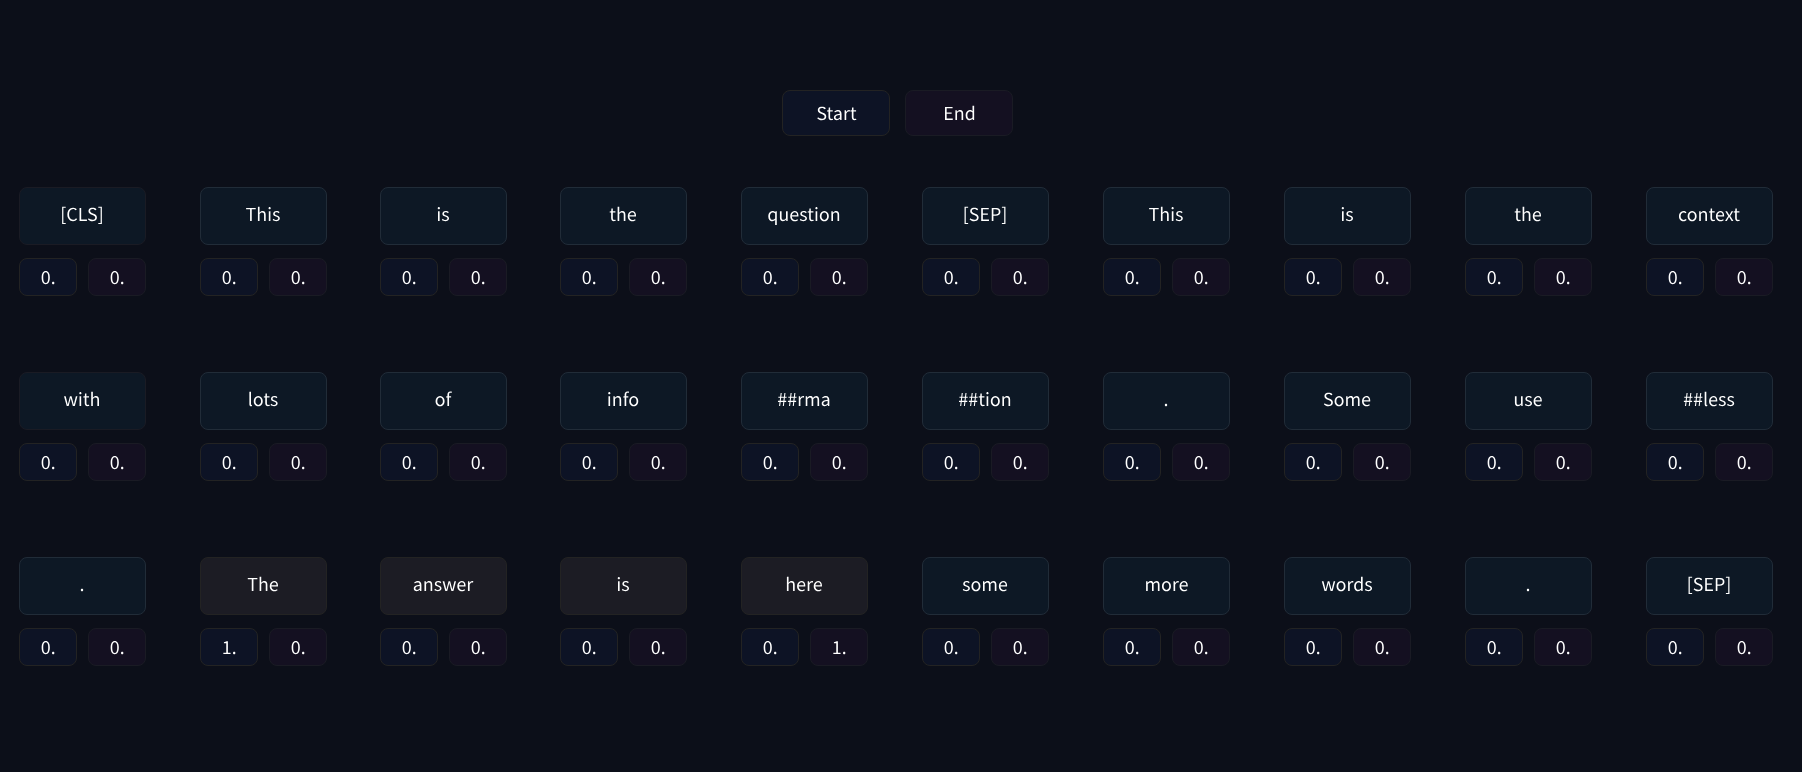

We can limit the length to 100 and use a sliding window of 50 tokens. As a reminder, we use:

- max_length to set the maximum length (here 100)
- truncation="only_second" to truncate the context (which is in the second position) when the question with its context is too long
- stride to set the number of overlapping tokens between two successive chunks (here 50)
- return_overflowing_tokens=True to let the tokenizer know we want the overflowing tokens

In [14]:
inputs = tokenizer(
    question,
    context,
    max_length=100,
    truncation='only_second',
    stride=50,
    return_overflowing_tokens=True,
)

for ids in inputs['input_ids']:
  print(tokenizer.decode(ids))

[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building ' s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basi [SEP]
[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin [SEP]
[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Next to the Main Building is the

As we can see, our example has been in split into four inputs, each of them containing the question and some part of the context. Note that the answer to the question (“Bernadette Soubirous”) only appears in the third and last inputs, so by dealing with long contexts in this way we will create some training examples where the answer is not included in the context. For those examples, the labels will be start_position = end_position = 0 (so we predict the [CLS] token). We will also set those labels in the unfortunate case where the answer has been truncated so that we only have the start (or end) of it. For the examples where the answer is fully in the context, the labels will be the index of the token where the answer starts and the index of the token where the answer ends.

The dataset provides us with the start character of the answer in the context, and by adding the length of the answer, we can find the end character in the context. To map those to token indices, we will need to use the offset mappings. We can have our tokenizer return these by passing along return_offsets_mapping=True:

In [18]:
inputs = tokenizer(
    question,
    context,
    max_length=100,
    truncation='only_second',
    stride=50,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
)
inputs.keys()

KeysView({'input_ids': [[101, 1706, 2292, 1225, 1103, 6567, 2090, 9273, 2845, 1107, 8109, 1107, 10111, 20500, 1699, 136, 102, 22182, 1193, 117, 1103, 1278, 1144, 170, 2336, 1959, 119, 1335, 4184, 1103, 4304, 4334, 112, 188, 2284, 10945, 1110, 170, 5404, 5921, 1104, 1103, 6567, 2090, 119, 13301, 1107, 1524, 1104, 1103, 4304, 4334, 1105, 4749, 1122, 117, 1110, 170, 7335, 5921, 1104, 4028, 1114, 1739, 1146, 14089, 5591, 1114, 1103, 7051, 107, 159, 21462, 1566, 24930, 2508, 152, 1306, 3965, 107, 119, 5893, 1106, 1103, 4304, 4334, 1110, 1103, 19349, 1104, 1103, 11373, 4641, 119, 13301, 1481, 1103, 171, 17506, 102], [101, 1706, 2292, 1225, 1103, 6567, 2090, 9273, 2845, 1107, 8109, 1107, 10111, 20500, 1699, 136, 102, 1103, 4304, 4334, 1105, 4749, 1122, 117, 1110, 170, 7335, 5921, 1104, 4028, 1114, 1739, 1146, 14089, 5591, 1114, 1103, 7051, 107, 159, 21462, 1566, 24930, 2508, 152, 1306, 3965, 107, 119, 5893, 1106, 1103, 4304, 4334, 1110, 1103, 19349, 1104, 1103, 11373, 4641, 119, 13301, 1481, 

As we can see, we get back the usual input IDs, token type IDs, and attention mask, as well as the offset mapping we required and an extra key, overflow_to_sample_mapping. The corresponding value will be of use to use when we tokenize several texts at the same time (which we should do to benefit from the fact that our tokenizer is backed by Rust) Since one sample can give several features, it maps each feature to the example it originated from. Because here we only tokenize one example, we get a list of 0s:

In [21]:
inputs['overflow_to_sample_mapping']

[0, 0, 0, 0]

But if we tokenize more examples, this will become more useful:

In [22]:
inputs = tokenizer(
    raw_datasets['train'][2:6]['question'],
    raw_datasets['train'][2:6]['context'],
    max_length=100,
    truncation='only_second',
    stride=50,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
)

print(f"The 4 examples gave {len(inputs['input_ids'])} features.")
print(f"Here is where each comes from: {inputs['overflow_to_sample_mapping']}.")

The 4 examples gave 19 features.
Here is where each comes from: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3].


As we can see, the first three examples (at indices 2, 3, and 4 in the training set) each gave four features and the last example (at index 5 in the training set) gave 7 features.

This info will be useful to map each feature to get its corresponding label/

To find the positions of the tokens, we first find the indices that start and end the context in the input IDs. We could use the token type IDs to do this, but since those do not necessarily exist for all models (DistilBERT does not require them, for instance), we'll instead use the sequence_ids() method of the BatchEncoding our tokenizer returns.

Once we have those token indices, we look at the corresponding offsets, which are tuples of two integers representing the span of characters inside the original context. We can thus detect if the chunk of the context in this feature starts after the answer or ends before the answer begins (in which case the label is (0, 0)). If that's not the case, we loop to find the first and last token of the answer:

In [25]:
answers = raw_datasets['train'][2:6]['answers']
start_positions = []
end_positions = []

for i, offset in enumerate(inputs['offset_mapping']):
  sample_idx = inputs['overflow_to_sample_mapping'][i]
  answer = answers[sample_idx]
  start_char = answer['answer_start'][0]
  end_char = answer['answer_start'][0] + len(answer['text'][0])
  sequence_ids = inputs.sequence_ids(i)

  # Find the start and end of the context
  idx = 0
  while sequence_ids[idx] != 1:
    idx += 1
  context_start = idx
  while sequence_ids[idx] == 1:
    idx += 1
  context_end = idx - 1

  # If the answer is not fully inside the context, label is (0, 0)
  if offset[context_start][0] > start_char or offset[context_end][1] < end_char:
    start_positions.append(0)
    end_positions.append(0)
  else:
    # Otherwise it's the start and end token positions
    idx = context_start
    while idx <= context_end and offset[idx][0] <= start_char:
      idx += 1
    start_positions.append(idx - 1)

    idx = context_end
    while idx >= context_start and offset[idx][1] >= end_char:
      idx -= 1
    end_positions.append(idx + 1)

start_positions, end_positions

([83, 51, 19, 0, 0, 64, 27, 0, 34, 0, 0, 0, 67, 34, 0, 0, 0, 0, 0],
 [85, 53, 21, 0, 0, 70, 33, 0, 40, 0, 0, 0, 68, 35, 0, 0, 0, 0, 0])

Let's take a look at a few results to verify that our approach is correct. For the first feature we find (83, 85) as labels, so let's compare the theoretical answer with the decoded span of tokens from 83 to 85 (inclusive):

In [28]:
idx = 0
sample_idx = inputs['overflow_to_sample_mapping'][idx]
answer = answers[sample_idx]['text'][0]

start = start_positions[idx]
end = end_positions[idx]
labeled_ans = tokenizer.decode(inputs['input_ids'][idx][start:end+1])

print(f"Theoretical answer: {answer}, labels give: {labeled_ans}")

Theoretical answer: the Main Building, labels give: the Main Building


So that's a match! Now let's check index 4, where we set the labels to (0, 0), which means the answer is not in the context chunk of that feature:

In [35]:
idx = 4
sample_idx = inputs['overflow_to_sample_mapping'][idx]
answer = answers[sample_idx]['text'][0]

decoded_example = tokenizer.decode(inputs['input_ids'][idx])
print(f"Theoretical ans: {answer}, decoded example: {decoded_example}")

Theoretical ans: a Marian place of prayer and reflection, decoded example: [CLS] What is the Grotto at Notre Dame? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building ' s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grot [SEP]


Indeed we don't see the answer inside the context

✏️ Your turn! When using the XLNet architecture, padding is applied on the left and the question and context are switched. Adapt all the code we just saw to the XLNet architecture (and add padding=True). Be aware that the [CLS] token may not be at the 0 position with padding applied.

Now that we have seen step by step how to preprocess the training data, we can group it into a function we will apply on the whole training dataset. We'll pad every feature to the maximum length we set, as most of the contexts will be long (and the corresponding samples will be split into several features), so there is no real benefit to applying dynamic padding here:

In [36]:
max_length = 384
stride = 128


def preprocess_training_examples(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=max_length,
        truncation="only_second",
        stride=stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    sample_map = inputs.pop("overflow_to_sample_mapping")
    answers = examples["answers"]
    start_positions = []
    end_positions = []

    for i, offset in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        answer = answers[sample_idx]
        start_char = answer["answer_start"][0]
        end_char = answer["answer_start"][0] + len(answer["text"][0])
        sequence_ids = inputs.sequence_ids(i)

        # Find the start and end of the context
        idx = 0
        while sequence_ids[idx] != 1:
            idx += 1
        context_start = idx
        while sequence_ids[idx] == 1:
            idx += 1
        context_end = idx - 1

        # If the answer is not fully inside the context, label is (0, 0)
        if offset[context_start][0] > start_char or offset[context_end][1] < end_char:
            start_positions.append(0)
            end_positions.append(0)
        else:
            # Otherwise it's the start and end token positions
            idx = context_start
            while idx <= context_end and offset[idx][0] <= start_char:
                idx += 1
            start_positions.append(idx - 1)

            idx = context_end
            while idx >= context_start and offset[idx][1] >= end_char:
                idx -= 1
            end_positions.append(idx + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

Note that we defined two constants to determine the max length used as well as the length of the sliding window, and that we added a tiny bit of cleanup before tokenizing: some of the questions in the SQuAD dataset have extra spaces at the beginning and tbe end that don't add anything (and take up space when being tokenized if we use a model like RoBERTa), so we removed those extra spaces:

To apply this function to the whole training set, we use the Dataset.map() method with the batched=True flag. It's necessary here as we are changing the length of the dataset (since one example can give several training features):

In [37]:
train_dataset = raw_datasets['train'].map(
    preprocess_training_examples,
    batched=True,
    remove_columns=raw_datasets['train'].column_names,
)
len(raw_datasets['train']), len(train_dataset)

Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

(87599, 88729)

As we can see, the preprocessing added roughly 1000 features. Our training set is now ready to be used -- let's dig into the preprocessing of the validation set!

## Preprocessing of the validation data ##

Preprocessing the validation data will be slightly easier as we don’t need to generate labels (unless we want to compute a validation loss, but that number won’t really help us understand how good the model is). The real joy will be to interpret the predictions of the model into spans of the original context. For this, we will just need to store both the offset mappings and some way to match each created feature to the original example it comes from. Since there is an ID column in the original dataset, we’ll use that ID.

The only thing we’ll add here is a tiny bit of cleanup of the offset mappings. They will contain offsets for the question and the context, but once we’re in the post-processing stage we won’t have any way to know which part of the input IDs corresponded to the context and which part was the question (the sequence_ids() method we used is available for the output of the tokenizer only). So, we’ll set the offsets corresponding to the question to None:

In [43]:
def preprocess_validation_examples(examples):
  questions = [q.strip() for q in examples['question']]
  inputs = tokenizer(
      questions,
      examples['context'],
      max_length=max_length,
      truncation='only_second',
      stride=stride,
      return_overflowing_tokens=True,
      return_offsets_mapping=True,
      padding='max_length'
  )

  sample_map = inputs.pop('overflow_to_sample_mapping')
  example_ids = []

  for i in range(len(inputs['input_ids'])):
    sample_idx = sample_map[i]
    example_ids.append(examples['id'][sample_idx])

    sequence_ids = inputs.sequence_ids(i)
    offset = inputs['offset_mapping'][i]
    inputs['offset_mapping'][i] = [
        o if sequence_ids[k] == 1 else None for k, o in enumerate(offset)
    ]
  inputs['example_id'] = example_ids
  return inputs

We can apply this func on the whole validation dataset like before:

In [44]:
validation_dataset = raw_datasets['validation'].map(
    preprocess_validation_examples,
    batched=True,
    remove_columns=raw_datasets['validation'].column_names,
)
len(raw_datasets['validation']), len(validation_dataset)

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

(10570, 10822)

In this case we’ve only added a couple of hundred samples, so it appears the contexts in the validation dataset are a bit shorter.

Now that we have preprocessed all the data, we can get to the training.

## Fine-tuning the model with the Trainer API ##

The training code for this example will look a lot like the code previously written in the latest sections of this course - the hardest thing will be to write the compute_metrics() function. Since we padded all the samples to the max length we set, there is no data collator to define, so this metric computation is really the only thing we have to worry about. The difficult part will be to post-process the model predictions into spans of text in the original examples; once we have done that, the metric in the HuggingFace Datasets library will do most of the work for us.

## Post-processing ##